# Phase 4 — Evaluation & Interpretation

**Goal of this notebook:** Quantitatively and qualitatively evaluate all representations from Phases 2 and 3. We will assess how well the embeddings separate experimental conditions and critically discuss limitations, including signal strength and inter-subject variability.

**Methodology:**
1. **Unsupervised Alignment:** K-Means clustering evaluated with Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI).
2. **Supervised Proxy & Domain Shift:** k-Nearest Neighbors evaluated using both Standard 5-Fold CV and Leave-One-Subject-Out (LOSO) CV.
3. **Feature Engineering Impact:** We will systematically compare the representations built on subject-normalized data (`X_subjz`) versus within-round deltas (`Delta`).

## Set up

Imports and data loading

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')
sns.set_theme(context='notebook', style='whitegrid')
RNG_SEED = 42

# paths
PHASE1_PATH = Path('artifacts/case2_phase1/case2_phase1_bundle.pkl')
PHASE3_PATH = Path('artifacts/case2_phase3/case2_phase3_embeddings.pkl')
ART_DIR = Path('artifacts/case2_phase4')
FIG_DIR = Path('figures/case2_phase4')
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# load data
bundle_p1 = joblib.load(PHASE1_PATH)
bundle_p3 = joblib.load(PHASE3_PATH)

# Extract Labels
y_phase  = bundle_p3['phase_labels']
subjects = bundle_p3['subject_ids']

# Create 2-class target: 'Stress' (phase2) vs 'Resting' (phase1 & phase3)
y_binary = np.where(y_phase == 'phase2', 'Stress', 'Resting')

print("Data loaded successfully")

Data loaded successfully


### The embeddings

In [2]:
# Unpack the best embeddings identified in phase 3
tsne_perp = bundle_p3['tsne_repr_perp']
umap_keys = (bundle_p3['umap_repr_nn'], bundle_p3['umap_repr_md'])

# Subject-normalized embeddings (X_subjz)
emb_subjz = {
    'PCA (Subjz)': bundle_p3['pca_2d'],
    't-SNE (Subjz)': bundle_p3['tsne_embeddings'][tsne_perp],
    'UMAP (Subjz)': bundle_p3['umap_embeddings'][umap_keys]
}

# Within-round delta embeddings
emb_delta = {
    'PCA (Delta)': bundle_p3['pca_delta_2d'],
    't-SNE (Delta)': bundle_p3['tsne_delta'],
    'UMAP (Delta)': bundle_p3['umap_delta']
}

# Combine for iteration
all_embeddings = {**emb_subjz, **emb_delta}
print(f"Evaluating {len(all_embeddings)} distinct representations.")

Evaluating 6 distinct representations.


# Unsupervised & Supervised Metrics

In [3]:
results = []

# Set up supervised classifier and CV schemes for proxy evaluation
clf = KNeighborsClassifier(n_neighbors=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
logo = LeaveOneGroupOut()

for name, emb in all_embeddings.items():
    # unsupervised clustering
    # 3-Class
    km3 = KMeans(n_clusters=3, random_state=RNG_SEED, n_init=10).fit_predict(emb)
    ari_3 = adjusted_rand_score(y_phase, km3)
    nmi_3 = normalized_mutual_info_score(y_phase, km3)
    
    # 2-Class
    km2 = KMeans(n_clusters=2, random_state=RNG_SEED, n_init=10).fit_predict(emb)
    ari_2 = adjusted_rand_score(y_binary, km2)
    
    # Supervised classification using KNN with both CV schemes
    # 3-Class Validation
    std_cv_3 = cross_val_score(clf, emb, y_phase, cv=skf, scoring='accuracy').mean()
    loso_cv_3 = cross_val_score(clf, emb, y_phase, groups=subjects, cv=logo, scoring='accuracy').mean()
    
    # 2-Class Validation
    std_cv_2 = cross_val_score(clf, emb, y_binary, cv=skf, scoring='accuracy').mean()
    loso_cv_2 = cross_val_score(clf, emb, y_binary, groups=subjects, cv=logo, scoring='accuracy').mean()
    
    # Store the results
    results.append({
        'Method': name,
        'ARI (3-Class)': ari_3,
        'NMI (3-Class)': nmi_3,
        'ARI (2-Class)': ari_2,
        'Std CV (3-Class)': std_cv_3,
        'LOSO CV (3-Class)': loso_cv_3,
        'Std CV (2-Class)': std_cv_2,
        'LOSO CV (2-Class)': loso_cv_2
    })

# Compile a result table
df_results = pd.DataFrame(results).set_index('Method')

# Display the results
print("Evaluation metrics results:")
display(df_results.round(3))

Evaluation metrics results:


,ARI (3-Class),NMI (3-Class),ARI (2-Class),Std CV (3-Class),LOSO CV (3-Class),Std CV (2-Class),LOSO CV (2-Class)
Method,,,,,,,
PCA (Subjz),0.096,0.108,0.071,0.503,0.490,0.734,0.721
t-SNE (Subjz),0.074,0.071,0.080,0.493,0.497,0.725,0.737
UMAP (Subjz),0.047,0.051,0.087,0.468,0.503,0.753,0.747
PCA (Delta),0.046,0.127,0.069,0.747,0.721,0.738,0.728
t-SNE (Delta),0.198,0.198,0.105,0.657,0.718,0.696,0.750
UMAP (Delta),0.348,0.368,0.160,0.679,0.760,0.731,0.769


Observe that for the X_subjz the linear PCA got better score than the non-linear methods, while for the Delta features the non-linear methods achieved the highes score. The ARI scores are also a lot higher for the Delta features than for X_subjz.

The supervides classification shows that the Delta performed much better, and notably in this case these is slmost no difference between the linear and non-linear methods.

# Plot of accuracy

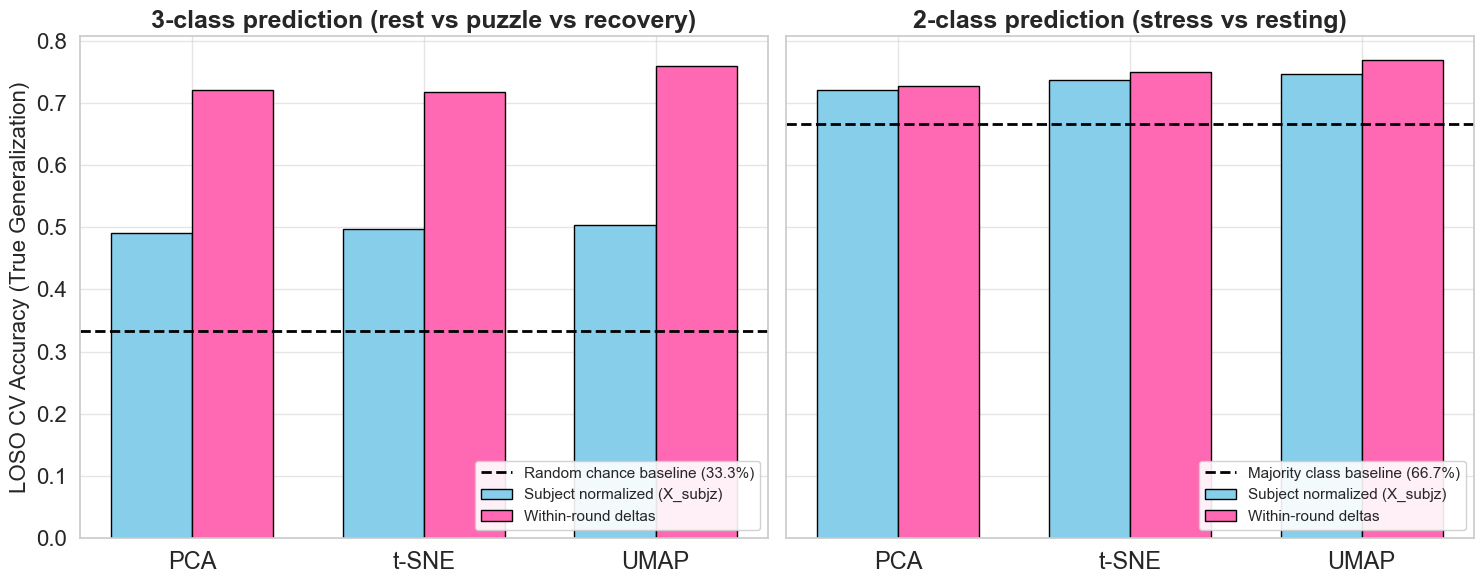

In [4]:
# Extract data for plotting
methods = ['PCA', 't-SNE', 'UMAP']
loso_3_subjz = [df_results.loc[f'{m} (Subjz)', 'LOSO CV (3-Class)'] for m in methods]
loso_3_delta = [df_results.loc[f'{m} (Delta)', 'LOSO CV (3-Class)'] for m in methods]

loso_2_subjz = [df_results.loc[f'{m} (Subjz)', 'LOSO CV (2-Class)'] for m in methods]
loso_2_delta = [df_results.loc[f'{m} (Delta)', 'LOSO CV (2-Class)'] for m in methods]

x = np.arange(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Adjusting the sizing
axes[0].legend(loc='lower right', fontsize=12)
axes[1].legend(loc='lower right', fontsize=12)
axes[0].tick_params(axis='y', labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)

# 3-class prediction (rest vs puzzle vs recovery)
axes[0].bar(x - width/2, loso_3_subjz, width, label='Subject normalized (X_subjz)', color='skyblue', edgecolor='black')
axes[0].bar(x + width/2, loso_3_delta, width, label='Within-round deltas', color='hotpink', edgecolor='black')
axes[0].axhline(y=0.333, color='black', linestyle='--', linewidth=2, label='Random chance baseline (33.3%)')

axes[0].set_title('3-class prediction (rest vs puzzle vs recovery)', fontsize=18, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=17)
axes[0].set_ylabel('LOSO CV Accuracy (True Generalization)', fontsize=16)
axes[0].legend(loc='lower right', framealpha=0.9)

# 2-class prediction (stress vs resting)
axes[1].bar(x - width/2, loso_2_subjz, width, label='Subject normalized (X_subjz)', color='skyblue', edgecolor='black')
axes[1].bar(x + width/2, loso_2_delta, width, label='Within-round deltas', color='hotpink', edgecolor='black')
axes[1].axhline(y=0.667, color='black', linestyle='--', linewidth=2, label='Majority class baseline (66.7%)')

axes[1].set_title('2-class prediction (stress vs resting)', fontsize=18, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, fontsize=17)
axes[1].legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'loso_comparison.pdf', format='pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'loso_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Conclusions from this notebook

**1. The "Generalization Challenge" and Domain Shift Resilience**
A major concern with wearable biosignals is domain shift, that models learn individual subject baselines rather than universal physiological states. Our evaluation proves our pipeline successfully mitigated this. The Leave-One-Subject-Out (LOSO) CV accuracy remained nearly identical to the Standard CV accuracy across all models, seen in the table. The model did not "cheat" by memorizing subjects, it learned a weak but truly generalizable physiological state that applies to unseen participants.

**2. The Power of Feature Engineering**
As seen in the results metrics table and visualization, non-linear models (t-SNE, UMAP) provided almost zero improvement over linear PCA for subjz. However, changing the feature space drastically improved performance. By transitioning from `X_subjz` (global subject normalization) to `Delta` features (within-round changes from baseline), the unsupervised ARI scores increased from near zero to distinct alignment, and LOSO predictive accuracy notably improved. This proves that calculating physiological change from rest is far more critical than utilizing complex manifold learning algorithms. 

**3. The Statistical Baseline Reality Check**
While our 2-class (Stress vs. Resting) predictive accuracies appear high (~66-70%), our rigorous evaluation acknowledges the severe class imbalance (Resting constitutes 66.7% of the data). Therefore, a 67% accuracy merely reflects the majority class baseline. This rigorous "Null Result" proves mathematically what the case study suspected: cross-sectional Empatica E4 biosignals are intensely noisy, and separating these specific psychological states requires feature representations that actively isolate immediate stimulus responses (like our Delta block).